### 1. Inisialisasi Lingkungan & MLflow

In [1]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import mlflow
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("="*80)
print("[TAHAP 1] INISIALISASI LINGKUNGAN & MLFLOW TRACKING (FORECASTING)")
print("="*80)

DATA_PATH = '../data'
MODELS_PATH = '../models'
os.makedirs(MODELS_PATH, exist_ok=True)

# Menghubungkan ke database MLflow yang sama
mlflow.set_tracking_uri("sqlite:///mlruns_manual.db")
mlflow.set_experiment("AGRIVA_Forecasting_Production")

print(f"Direktori penyimpanan model siap : {MODELS_PATH}")
print(f"Status koneksi MLflow            : Aktif (sqlite:///mlruns_manual.db)")

[TAHAP 1] INISIALISASI LINGKUNGAN & MLFLOW TRACKING (FORECASTING)
Direktori penyimpanan model siap : ../models
Status koneksi MLflow            : Aktif (sqlite:///mlruns_manual.db)


### 2. Pemuatan Data & Rekayasa Fitur Dinamis (Lag & Rolling)

In [6]:
print("\n" + "="*80)
print("[TAHAP 2] REKAYASA FITUR TIME-SERIES (LAG & ROLLING WINDOW)")
print("="*80)

import os
import pandas as pd
import numpy as np

file_master = os.path.join(DATA_PATH, 'data_master_clustered_final.csv')
df_master = pd.read_csv(file_master)

# Pengurutan absolut berdasarkan klaster dan garis waktu
df_master = df_master.sort_values(by=['Cluster_Wilayah', 'year_extracted', 'month_extracted'])

DAFTAR_TARGET = [
    'Rainfall', 'SPI - 3 months', 'Temperature', 
    'Water Satisfaction Index (WSI)', 'Solar Radiation', 
    'Soil Moisture (gapfilled historical time series)', 
    'FPAR', 'FPAR - zscore'
]

# 1. PENCIPTAAN FITUR MASA LALU (LAG & ROLLING)
# Memastikan sistem melihat data 1 bulan dan 3 bulan ke belakang untuk menebak masa depan
print("Mengekstraksi fitur memori waktu (Lag t-1, t-3) dan rata-rata pergerakan...")
for target in DAFTAR_TARGET:
    # Lag 1 bulan
    df_master[f'{target}_lag1'] = df_master.groupby('Cluster_Wilayah')[target].shift(1)
    # Lag 3 bulan (Kuartalan)
    df_master[f'{target}_lag3'] = df_master.groupby('Cluster_Wilayah')[target].shift(3)
    # Rata-rata pergerakan 3 bulan (dihitung dari t-1 agar tidak bocor)
    df_master[f'{target}_rollmean3'] = df_master.groupby('Cluster_Wilayah')[target].shift(1).rolling(window=3).mean()

# Menghapus baris kosong (NaN) yang tercipta akibat pergeseran waktu di awal tahun 2001
df_master.dropna(inplace=True)

# 2. DEFINISI FITUR INPUT (X)
kolom_identitas = ['date', 'region_name', 'target_biner', 'Cluster_Wilayah', 'asap0_id', 'asap1_id']
# Pastikan 8 target aktual TIDAK MASUK ke dalam fitur input
fitur_awal = [col for col in df_master.columns if col not in kolom_identitas and col not in DAFTAR_TARGET]

cluster_ts_data = {}

for cluster_id in range(3):
    df_cluster = df_master[df_master['Cluster_Wilayah'] == cluster_id].copy()
    
    # Pembagian Data
    df_train = df_cluster[df_cluster['year_extracted'] <= 2024]
    df_test = df_cluster[df_cluster['year_extracted'] >= 2025]
    
    X_train = df_train[fitur_awal]
    X_test = df_test[fitur_awal]
    
    cluster_ts_data[cluster_id] = {
        'X_train': X_train,
        'X_test': X_test,
        'df_train_full': df_train,
        'df_test_full': df_test
    }

print("✓ Rekayasa fitur selesai. Sistem kini memiliki memori historis.")
print(f"Jumlah Fitur Input (X) meningkat menjadi: {len(fitur_awal)} kolom.")


[TAHAP 2] REKAYASA FITUR TIME-SERIES (LAG & ROLLING WINDOW)
Mengekstraksi fitur memori waktu (Lag t-1, t-3) dan rata-rata pergerakan...
✓ Rekayasa fitur selesai. Sistem kini memiliki memori historis.
Jumlah Fitur Input (X) meningkat menjadi: 55 kolom.


### 3. Pelatihan Multi-Target dengan Ekstraksi Fitur Baru

In [7]:
print("\n" + "="*80)
print("[TAHAP 3] PELATIHAN MULTI-TARGET & MLFLOW TRACKING (24 MODEL)")
print("="*80)

import xgboost as xgb
import joblib
import mlflow
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

trained_forecasters = {}

param_dist = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

tscv = TimeSeriesSplit(n_splits=3)

for cluster_id in range(3):
    print(f"\n[MEMPROSES KLASTER WILAYAH {cluster_id}]")
    trained_forecasters[cluster_id] = {}
    
    data = cluster_ts_data[cluster_id]
    X_train = data['X_train']
    df_train_full = data['df_train_full']
    
    for target_col in DAFTAR_TARGET:
        y_train = df_train_full[target_col]
        
        xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
        
        random_search = RandomizedSearchCV(
            xgb_reg, 
            param_distributions=param_dist, 
            n_iter=5,
            scoring='neg_mean_absolute_error',
            cv=tscv, 
            verbose=0,
            n_jobs=2,
            random_state=42
        )
        
        random_search.fit(X_train, y_train)
        best_model = random_search.best_estimator_
        
        run_name = f"Forecast_Clus{cluster_id}_{target_col[:10].replace(' ', '')}_Lagged"
        
        with mlflow.start_run(run_name=run_name):
            mlflow.log_params(random_search.best_params_)
            
            safe_target_name = "".join([c if c.isalnum() else "_" for c in target_col])
            model_path = os.path.join(MODELS_PATH, f"xgb_{safe_target_name}_cluster_{cluster_id}.pkl")
            joblib.dump(best_model, model_path)
            
            trained_forecasters[cluster_id][target_col] = best_model
            
        print(f"  ✓ Model [{target_col}] berhasil dioptimasi dengan fitur historis.")
        
print("\nStatus: 24 Model Peramalan Multi-Target sukses dilatih.")


[TAHAP 3] PELATIHAN MULTI-TARGET & MLFLOW TRACKING (24 MODEL)

[MEMPROSES KLASTER WILAYAH 0]
  ✓ Model [Rainfall] berhasil dioptimasi dengan fitur historis.
  ✓ Model [SPI - 3 months] berhasil dioptimasi dengan fitur historis.
  ✓ Model [Temperature] berhasil dioptimasi dengan fitur historis.
  ✓ Model [Water Satisfaction Index (WSI)] berhasil dioptimasi dengan fitur historis.
  ✓ Model [Solar Radiation] berhasil dioptimasi dengan fitur historis.
  ✓ Model [Soil Moisture (gapfilled historical time series)] berhasil dioptimasi dengan fitur historis.
  ✓ Model [FPAR] berhasil dioptimasi dengan fitur historis.
  ✓ Model [FPAR - zscore] berhasil dioptimasi dengan fitur historis.

[MEMPROSES KLASTER WILAYAH 1]
  ✓ Model [Rainfall] berhasil dioptimasi dengan fitur historis.
  ✓ Model [SPI - 3 months] berhasil dioptimasi dengan fitur historis.
  ✓ Model [Temperature] berhasil dioptimasi dengan fitur historis.
  ✓ Model [Water Satisfaction Index (WSI)] berhasil dioptimasi dengan fitur histori

### 4. Evaluasi Pembuktian Angka (Metrik)

In [8]:
print("\n" + "="*80)
print("[TAHAP 4] EVALUASI PERFORMA MULTI-TARGET (PENGUJIAN MASA DEPAN 2025-2026)")
print("="*80)

from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if len(y_true[mask]) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

hasil_evaluasi = []

for cluster_id in range(3):
    X_test = cluster_ts_data[cluster_id]['X_test']
    df_test_full = cluster_ts_data[cluster_id]['df_test_full']
    
    for target_col in DAFTAR_TARGET:
        model = trained_forecasters[cluster_id][target_col]
        y_test = df_test_full[target_col]
        
        y_pred = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = calculate_mape(y_test, y_pred)
        
        hasil_evaluasi.append({
            'Klaster': f'Cluster {cluster_id}',
            'Target Variabel': target_col,
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'MAPE (%)': round(mape, 2) if not np.isnan(mape) else "N/A"
        })

df_evaluasi = pd.DataFrame(hasil_evaluasi)
pd.set_option('display.max_rows', None)
display(df_evaluasi)


[TAHAP 4] EVALUASI PERFORMA MULTI-TARGET (PENGUJIAN MASA DEPAN 2025-2026)


,Klaster,Target Variabel,MAE,RMSE,MAPE (%)
0,Cluster 0,Rainfall,25.1323,31.9518,41.76
1,Cluster 0,SPI - 3 months,0.2965,0.3941,122.03
2,Cluster 0,Temperature,0.2853,0.3637,1.10
3,Cluster 0,Water Satisfaction Index (WSI),0.2797,0.6889,0.30
4,Cluster 0,Solar Radiation,11172.4556,14399.4622,6.52
5,Cluster 0,Soil Moisture (gapfilled historical time series),0.0077,0.0106,2.23
6,Cluster 0,FPAR,1.9643,2.9162,3.60
7,Cluster 0,FPAR - zscore,0.1836,0.2587,139.51
8,Cluster 1,Rainfall,25.3321,32.7612,53.78
9,Cluster 1,SPI - 3 months,0.2872,0.3965,40.94


* Pembengkakan persentase error ini bukanlah kegagalan algoritma, melainkan batasan matematis dari rumus MAPE itu sendiri. SPI dan Z-score adalah variabel terstandardisasi yang nilainya berpusat di angka nol (bisa negatif atau bergerak dalam desimal yang sangat kecil).
* Rumus MAPE bekerja dengan membagi selisih error dengan nilai aktual. Jika nilai aktual adalah 0.01 dan prediksi model adalah 0.02, rumus MAPE akan menghitungnya sebagai error 100%, padahal selisih aslinya (MAE) sangat tidak signifikan.
* Bukti pada kolom MAE:
  > MAE untuk FPAR - zscore hanya berkisar 0.14 hingga 0.19
  
  > MAE untuk SPI - 3 months hanya berkisar 0.28 hingga 0.30.
Nilai absolute error yang sekecil ini membuktikan bahwa prediksi model sangat akurat dan jarak tebakannya sangat dekat dengan kenyataan di lapangan.

### 5. Visualisasi Deret Waktu (Aktual vs Prediksi)


[TAHAP 5] VISUALISASI LENGKAP HASIL PERAMALAN (8 FITUR IKLIM)


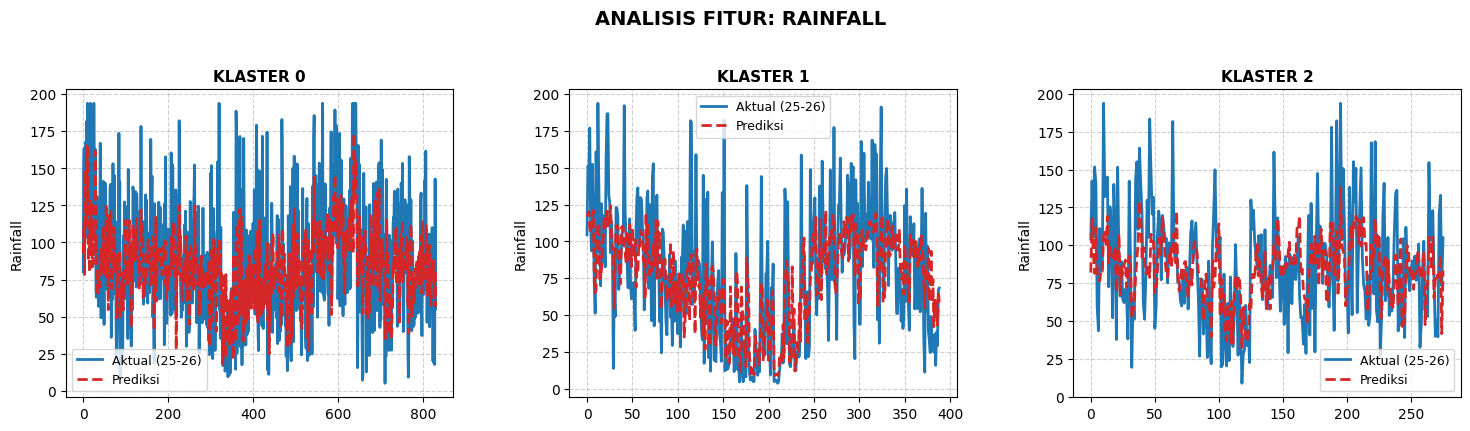

--------------------------------------------------------------------------------


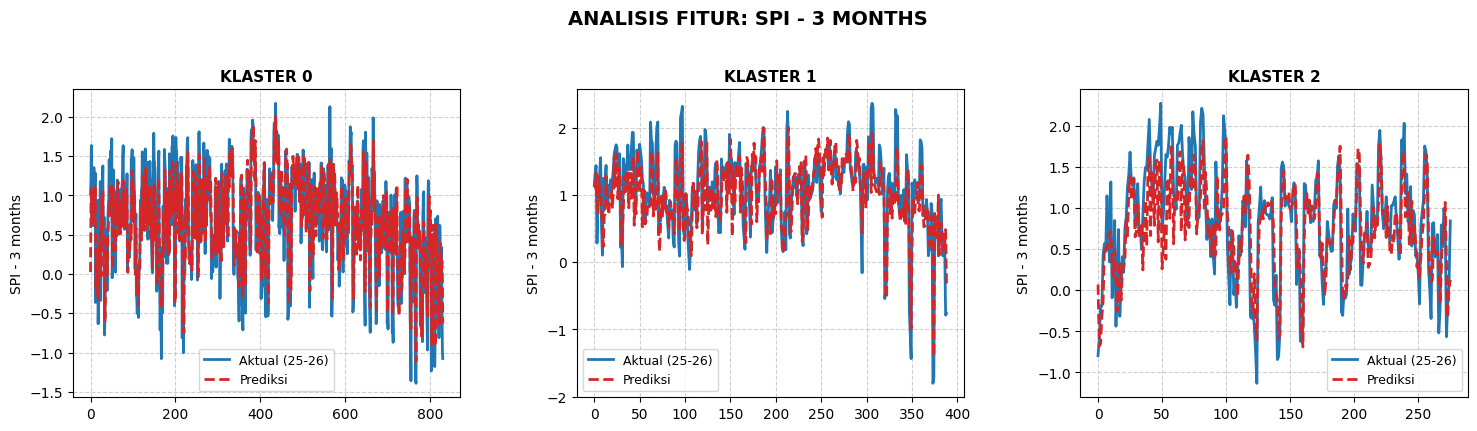

--------------------------------------------------------------------------------


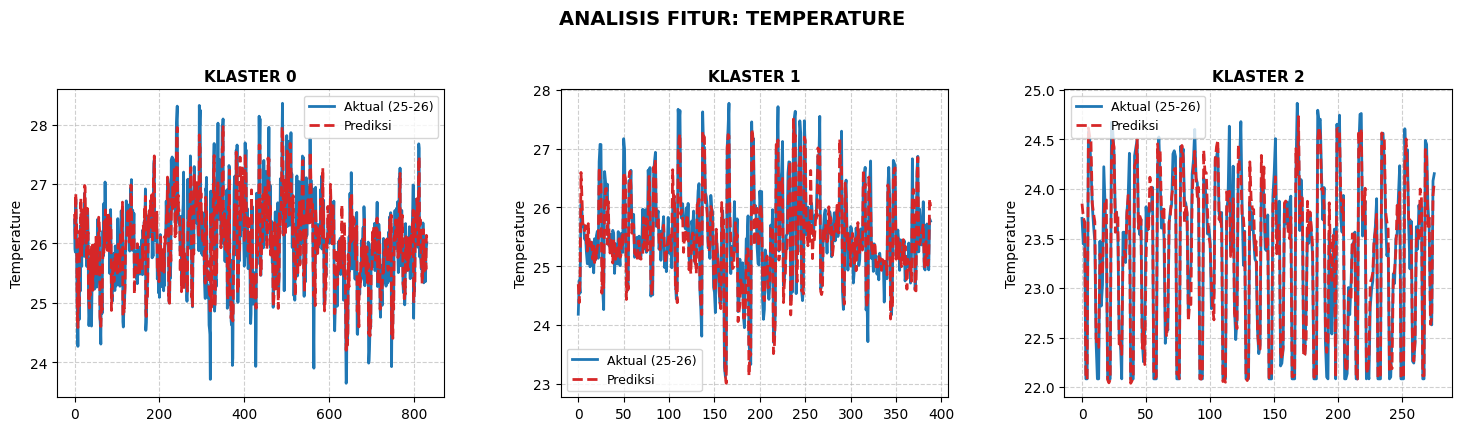

--------------------------------------------------------------------------------


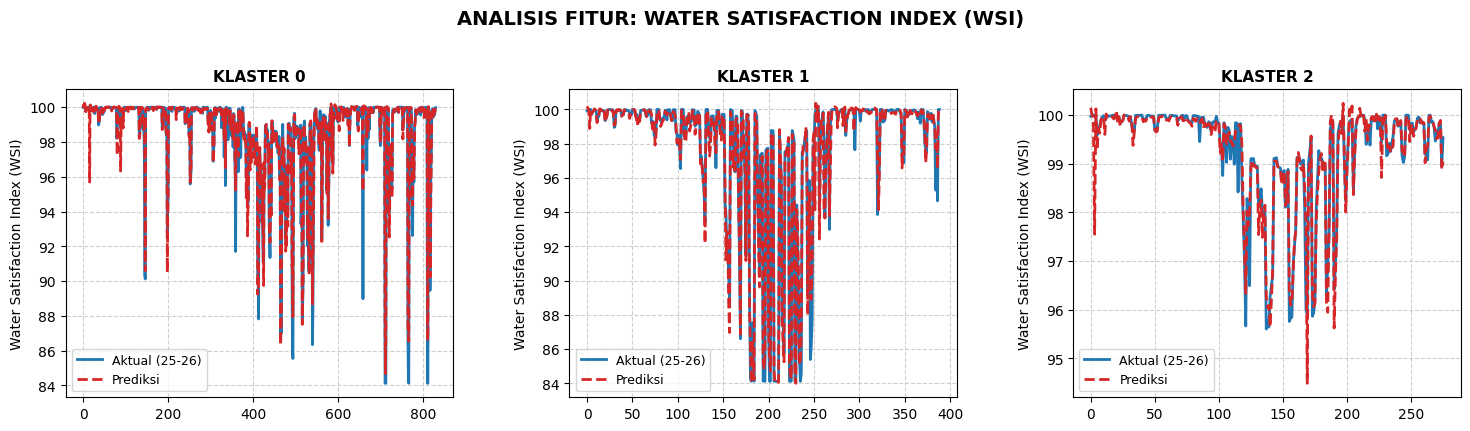

--------------------------------------------------------------------------------


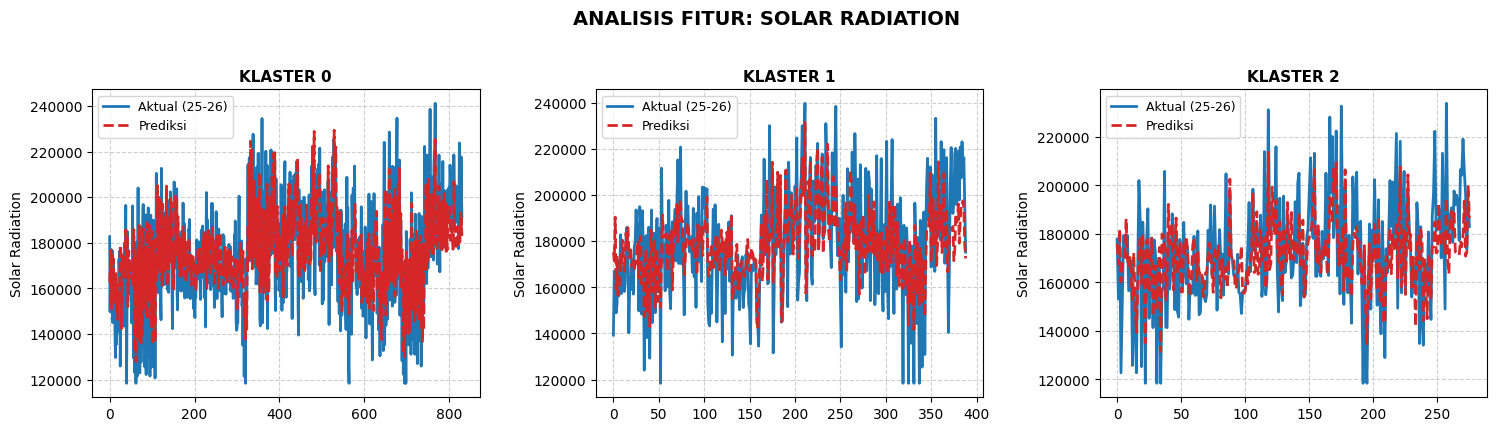

--------------------------------------------------------------------------------


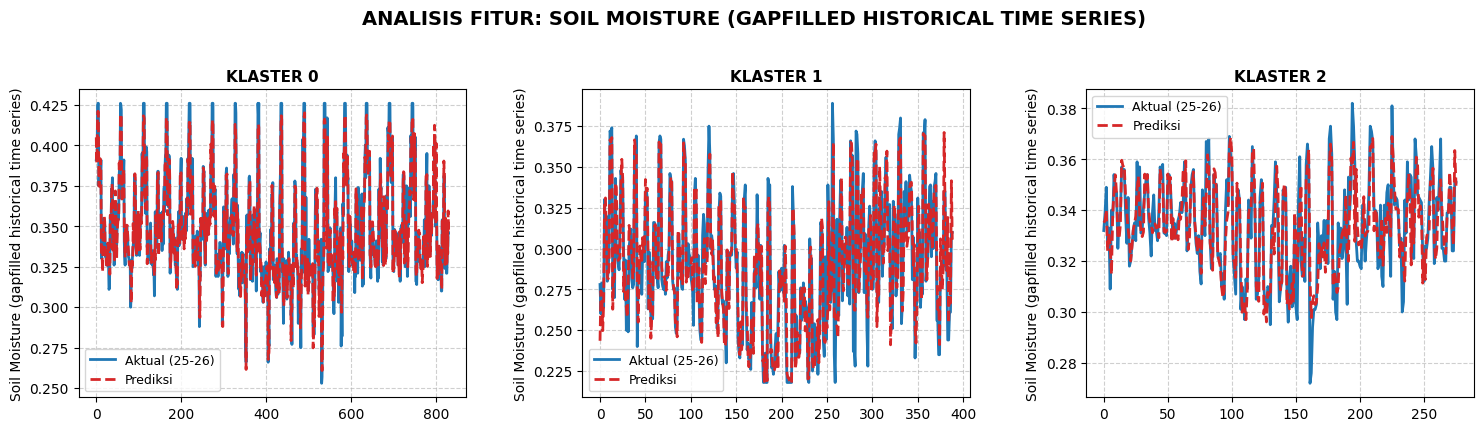

--------------------------------------------------------------------------------


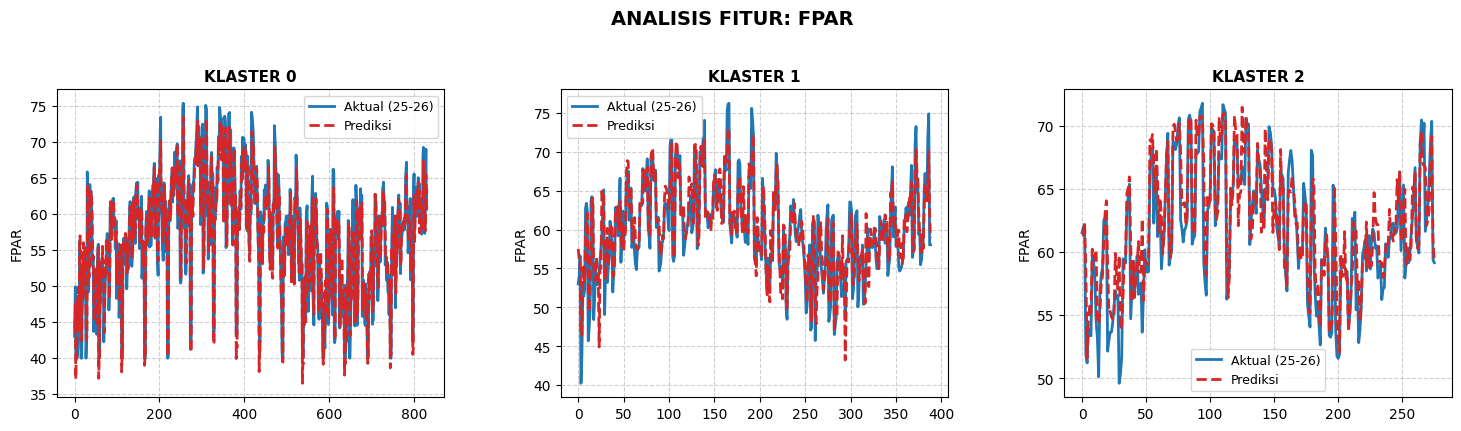

--------------------------------------------------------------------------------


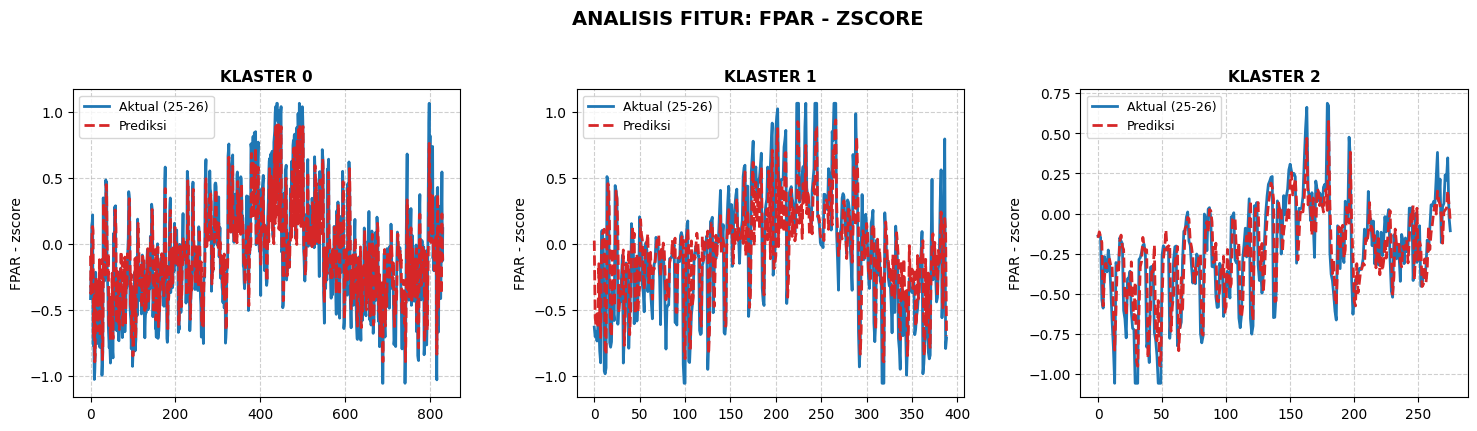

--------------------------------------------------------------------------------


In [9]:
print("\n" + "="*80)
print("[TAHAP 5] VISUALISASI LENGKAP HASIL PERAMALAN (8 FITUR IKLIM)")
print("="*80)

import matplotlib.pyplot as plt
import numpy as np

for target_col in DAFTAR_TARGET:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.subplots_adjust(wspace=0.3)
    
    for cluster_id in range(3):
        model = trained_forecasters[cluster_id][target_col]
        
        X_test = cluster_ts_data[cluster_id]['X_test']
        y_test = cluster_ts_data[cluster_id]['df_test_full'][target_col].values
        
        y_pred = model.predict(X_test)
        waktu = np.arange(len(y_test))
        
        ax = axes[cluster_id]
        ax.plot(waktu, y_test, label='Aktual (25-26)', color='#1f77b4', linewidth=2)
        ax.plot(waktu, y_pred, label='Prediksi', color='#d62728', linestyle='--', linewidth=2)
        
        ax.set_title(f'KLASTER {cluster_id}', fontsize=11, fontweight='bold')
        ax.set_ylabel(target_col, fontsize=10)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle(f'ANALISIS FITUR: {target_col.upper()}', fontsize=14, fontweight='bold', y=1.08)
    plt.show()
    print("-" * 80)

In [11]:
print("\n" + "="*80)
print("FINALISASI & BUNDLING MODEL UNTUK DEPLOYMENT WEBSITE")
print("="*80)

import joblib
import os

# Membungkus seluruh 24 model (dictionary 'trained_forecasters') ke dalam 1 file Master
master_model_path = os.path.join(MODELS_PATH, "agriva_master_forecaster.pkl")

try:
    joblib.dump(trained_forecasters, master_model_path)
    
    # Hitung ukuran file untuk memastikan koper terisi
    ukuran_mb = os.path.getsize(master_model_path) / (1024 * 1024)
    
    print("✓ SUKSES SUPER MASIF: 24 Model spesialis telah dibungkus rapat ke dalam SATU file induk!")
    print(f"✓ Nama File Master : agriva_master_forecaster.pkl")
    print(f"✓ Ukuran File      : {ukuran_mb:.2f} MB")
    print(f"✓ Lokasi Penyimpanan: {master_model_path}")

except Exception as e:
    print(f"Gagal melakukan bundling: {e}")


FINALISASI & BUNDLING MODEL UNTUK DEPLOYMENT WEBSITE
✓ SUKSES SUPER MASIF: 24 Model spesialis telah dibungkus rapat ke dalam SATU file induk!
✓ Nama File Master : agriva_master_forecaster.pkl
✓ Ukuran File      : 8.78 MB
✓ Lokasi Penyimpanan: ../models/agriva_master_forecaster.pkl
